# Overview

The kernel goes through

1. the preprocessing steps to load the data
2. a quick visualization of the color-space
3. training a simple CNN
4. applying the model to the test data
5. creating the RLE test data

In [6]:
import numpy as np
import pandas as pd
from glob import glob
import os
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
dsb_data_dir = os.path.join('.', 'input')
stage_label = 'stage1'

## Read in the labels

Load the RLE-encoded output for the training set

In [7]:
train_labels = pd.read_csv(os.path.join(dsb_data_dir, '{}_train_labels.csv'.format(stage_label)))
train_labels['EncodedPixels'] = train_labels['EncodedPixels'].map(lambda ep: [int(x) for x in ep.split(' ')])
train_labels.sample(3)

,ImageId,EncodedPixels
26912,e7a3a7c99483c243742b6cfa74e81cd48f126dcef00401...,"[430, 24, 950, 24, 1471, 22, 1992, 19, 2513, 1..."
625,0532c64c2fd0c4d3188cc751cdfd566b1cfba3d2693587...,"[15736, 22, 16091, 30, 16447, 35, 16806, 38, 1..."
1140,08275a5b1c2dfcd739e8c4888a5ee2d29f83eccfa75185...,"[826029, 1, 827052, 8, 828076, 9, 829100, 8, 8..."


## Load in all Images

Here we load in the images and process the paths so we have the appropriate information for each image

In [8]:
all_images = glob(os.path.join(dsb_data_dir, 'stage1_*', '*', '*', '*'))
img_df = pd.DataFrame({'path': all_images})
img_id = lambda in_path: in_path.split('\\')[-3]
img_type = lambda in_path: in_path.split('\\')[-2]
img_group = lambda in_path: in_path.split('\\')[-4].split('_')[1]
img_stage = lambda in_path: in_path.split('\\')[-4].split('_')[0]
img_df['ImageId'] = img_df['path'].map(img_id)
img_df['ImageType'] = img_df['path'].map(img_type)
img_df['TrainingSplit'] = img_df['path'].map(img_type)
img_df['Stage'] = img_df['path'].map(img_group)
img_df.sample(2)

,path,ImageId,ImageType,TrainingSplit,Stage
11375,.\input\stage1_train\5afb7932e9c7328f4fb1d7a81...,5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b9375...,masks,masks,train
26370,.\input\stage1_train\dbe5ad05b6f87018159a3228c...,dbe5ad05b6f87018159a3228c1d1725892a1bfb9fa9f8f...,images,images,train


In [9]:
img_df.head().iloc[0,0].split('/')

['.\\input\\stage1_test\\0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5\\images\\0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5.png']

## Create Training Data

Here we make training data and load all the images into the dataframe. We take a simplification here of grouping all the regions together (rather than keeping them distinct).

In [10]:
%%time
train_df = img_df.query('Stage=="train"')
train_rows = []
group_cols = ['Stage', 'ImageId']
for n_group, n_rows in train_df.groupby(group_cols):
    c_row = {col_name: col_value for col_name, col_value in zip(group_cols, n_group)}
    c_row['masks'] = n_rows.query('ImageType == "masks"')['path'].values.tolist()
    c_row['images'] = n_rows.query('ImageType == "images"')['path'].values.tolist()
    train_rows += [c_row]
train_img_df = pd.DataFrame(train_rows)
IMG_CHANNELS = 3
def read_and_stack(in_img_list):
    return np.sum(np.stack([imread(c_img) for c_img in in_img_list], 0), 0)/255.0
train_img_df['images'] = train_img_df['images'].map(read_and_stack).map(lambda x: x[:, :, :IMG_CHANNELS])
train_img_df['masks'] = train_img_df['masks'].map(read_and_stack).map(lambda x: x.astype(int))
train_img_df.sample(1)

CPU times: total: 4min 30s
Wall time: 20min 26s


,Stage,ImageId,masks,images
29,train,0b0d577159f0d6c266f360f7b8dfde46e16fa665138bf5...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.0392156862745098, 0.0392156862745098, 0.0..."


In [11]:
img_df

,path,ImageId,ImageType,TrainingSplit,Stage
0,.\input\stage1_test\0114f484a16c152baa2d82fdd4...,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,images,images,test
1,.\input\stage1_test\0999dab07b11bc85fb8464fc36...,0999dab07b11bc85fb8464fc36c947fbd8b5d6ec498173...,images,images,test
2,.\input\stage1_test\0a849e0eb15faa8a6d7329c3dd...,0a849e0eb15faa8a6d7329c3dd66aabe9a294cccb52ed3...,images,images,test
3,.\input\stage1_test\0e132f71c8b4875c3c2dd7a229...,0e132f71c8b4875c3c2dd7a22997468a3e842b46aa9bd4...,images,images,test
4,.\input\stage1_test\0ed3555a4bd48046d3b63d8baf...,0ed3555a4bd48046d3b63d8baf03a5aa97e523aa483aaa...,images,images,test
...,...,...,...,...,...
30191,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30192,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30193,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30194,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train


In [12]:
train_img_df

,Stage,ImageId,masks,images
0,train,00071198d059ba7f5914a526d124d28e6d010c92466da2...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.0196078431372549, 0.0196078431372549, 0.0..."
1,train,003cee89357d9fe13516167fd67b609a164651b2193458...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.0196078431372549, 0.0196078431372549, 0.0..."
2,train,00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b074...,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,...","[[[0.5098039215686274, 0.24313725490196078, 0...."
3,train,0121d6759c5adb290c8e828fc882f37dfaf3663ec885c6...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.7019607843137254, 0.6235294117647059, 0.7..."
4,train,01d44a26f6680c42ba94c9bc6339228579a95d0e2695b1...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.6784313725490196, 0.615686274509804, 0.76..."
...,...,...,...,...
665,train,fec226e45f49ab81ab71e0eaa1248ba09b56a328338dce...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.043137254901960784, 0.043137254901960784,..."
666,train,feffce59a1a3eb0a6a05992bb7423c39c7d52865846da3...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.050980392156862744, 0.050980392156862744,..."
667,train,ff3407842ada5bc18be79ae453e5bdaa1b68afc842fc22...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.047058823529411764, 0.047058823529411764,..."
668,train,ff3e512b5fb860e5855d0c05b6cf5a6bcc7792e4be1f0b...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.00784313725490196, 0.00784313725490196, 0..."


## Show a few images

Here we show a few images of the cells where we see there is a mixture of brightfield and fluorescence which will probably make using a single segmentation algorithm difficult

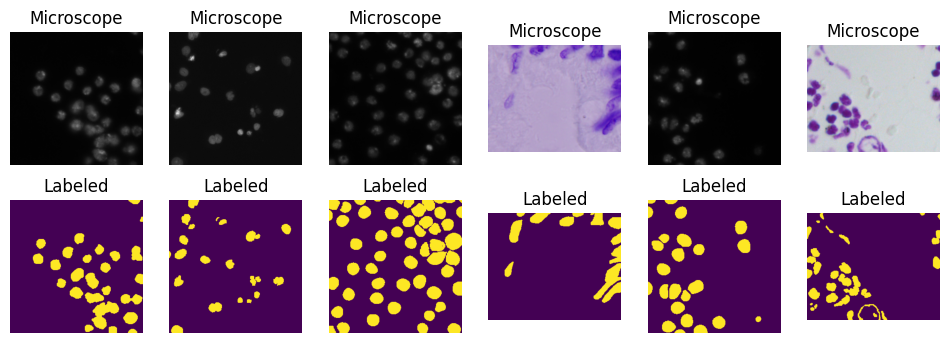

In [13]:
n_img = 6
fig, m_axs = plt.subplots(2, n_img, figsize=(12, 4))
for (_, c_row), (c_im, c_lab) in zip(train_img_df.sample(n_img).iterrows(), m_axs.T):
    c_im.imshow(c_row['images'])
    c_im.axis('off')
    c_im.set_title('Microscope')

    c_lab.imshow(c_row['masks'])
    c_lab.axis('off')
    c_lab.set_title('Labeled')

## Look at the intensity distribution

Here we look briefly at the distribution of intensity and see a few groups forming, they should probably be handled separately.

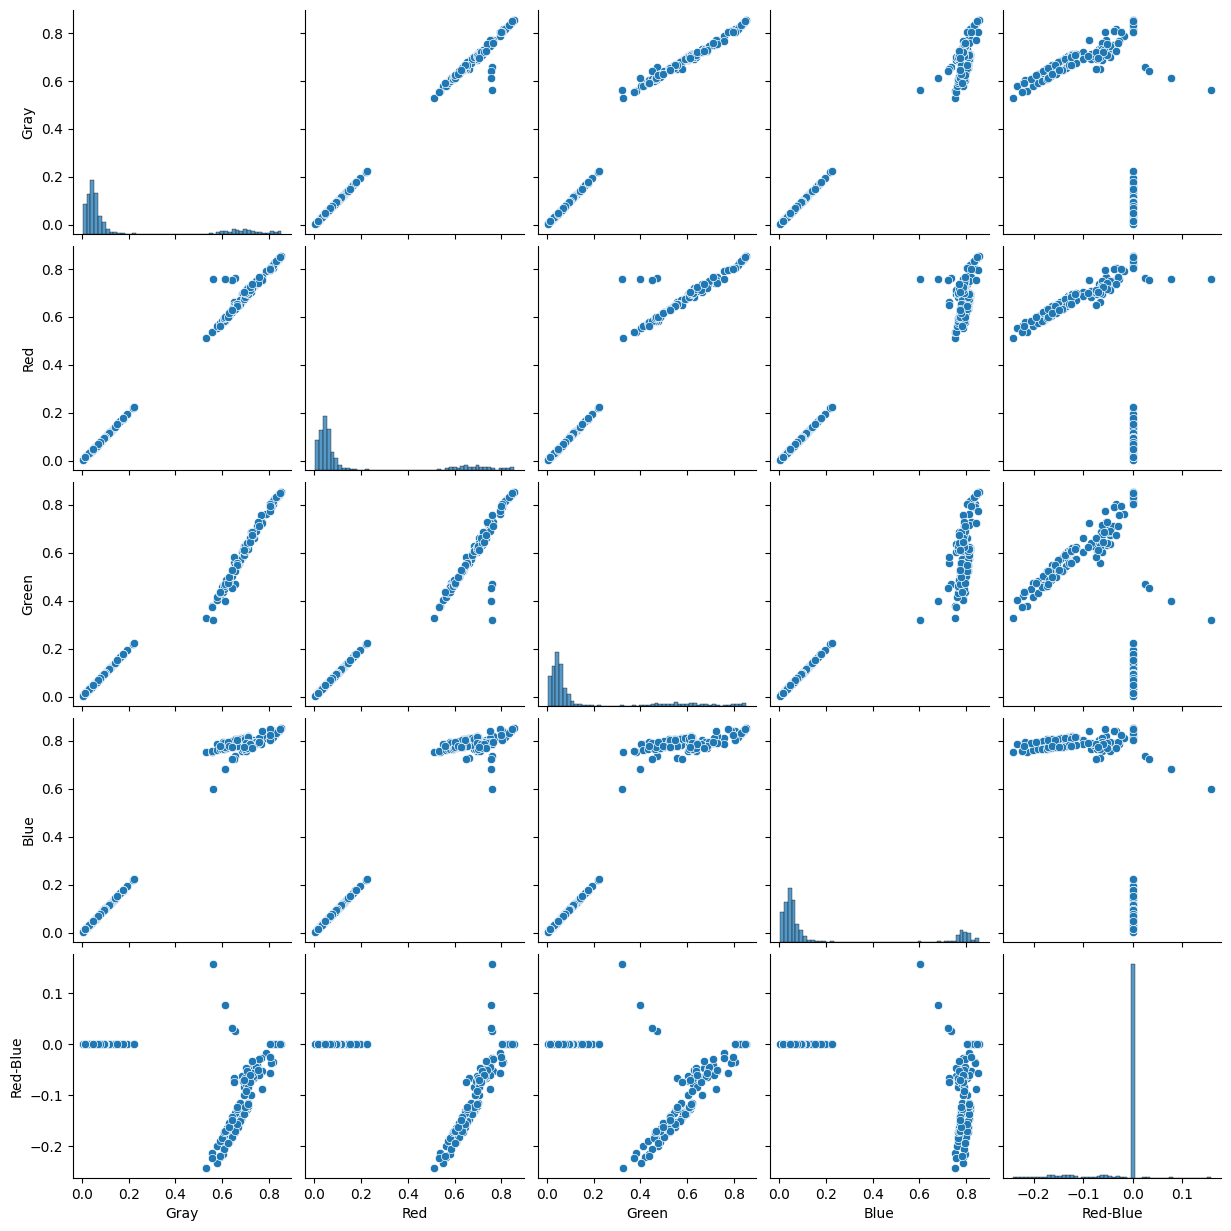

In [14]:
train_img_df['Red'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 0]))
train_img_df['Green'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 1]))
train_img_df['Blue'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 2]))
train_img_df['Gray'] = train_img_df['images'].map(lambda x: np.mean(x))
train_img_df['Red-Blue'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 0]-x[:, :, 2]))
sns.pairplot(train_img_df[['Gray', 'Red', 'Green', 'Blue', 'Red-Blue']])

## Check Dimensions

Here we show the dimensions of the data to see the variety in the input images

In [15]:
train_img_df['images'].map(lambda x: x.shape).value_counts()

images
(256, 256, 3)      334
(256, 320, 3)      112
(520, 696, 3)       92
(360, 360, 3)       91
(1024, 1024, 3)     16
(512, 640, 3)       13
(603, 1272, 3)       6
(260, 347, 3)        5
(1040, 1388, 3)      1
Name: count, dtype: int64

### Making a simple CNN

Here we make a very simple CNN just to get a quick idea of how well it works. For this we use a batch normalization to normalize the inputs. We cheat a bit with the padding to keep problems simple.

In [16]:
from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, UpSampling2D, Lambda


In [17]:
simple_cnn = Sequential()
simple_cnn.add(BatchNormalization(input_shape=(None, None, IMG_CHANNELS), name='NormalizeInput'))
simple_cnn.add(Conv2D(8, kernel_size=(3, 3), padding='same'))
simple_cnn.add(Conv2D(8, kernel_size=(3, 3), padding='same'))

simple_cnn.add(Conv2D(16, kernel_size=(3, 3), dilation_rate=2, padding='same'))
simple_cnn.add(Conv2D(16, kernel_size=(3, 3), dilation_rate=2, padding='same'))
simple_cnn.add(Conv2D(32, kernel_size=(3, 3), dilation_rate=3, padding='same'))

simple_cnn.add(Conv2D(16, kernel_size=(1, 1), padding='same'))
simple_cnn.add(Conv2D(1, kernel_size=(1, 1), padding='same', activation='sigmoid'))
simple_cnn.summary()

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ NormalizeInput                  │ (None, None, None, 3)  │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, None, 8)  │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 8)  │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None, 16) │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None, 16) │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, None, None, 32) │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, None, None, 16) │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, None, None, 1)  │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,493 (37.08 KB)

 Trainable params: 9,487 (37.06 KB)

 Non-trainable params: 6 (24.00 B)

## Loss

Since we are being evaluated with intersection over union we can use the inverse of the DICE score as the loss function to optimize

In [18]:
from keras import ops

smooth = 1.
def dice_coef(y_true, y_pred):
    y_true_f = ops.reshape(ops.cast(y_true, y_pred.dtype), [-1])
    y_pred_f = ops.reshape(y_pred, [-1])
    intersection = ops.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (ops.sum(y_true_f) + ops.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

simple_cnn.compile(optimizer='adam',
                   loss=dice_coef_loss,
                   metrics=[dice_coef, 'acc', 'mse'])

## Simple Training

Here we run a simple training, with each image being it's own batch (not a very good idea), but it keeps the code simple.

In [19]:
import tensorflow as tf

def simple_gen():
    while True:
        for _, c_row in train_img_df.iterrows():
            yield np.expand_dims(c_row['images'], 0), np.expand_dims(np.expand_dims(c_row['masks'], -1), 0)

train_ds = tf.data.Dataset.from_generator(
    simple_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, None, None, IMG_CHANNELS), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, None, 1), dtype=tf.float32),
    )
)

simple_cnn.fit(train_ds,
               steps_per_epoch=train_img_df.shape[0], epochs=3)

Epoch 1/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - acc: 0.8700 - dice_coef: 0.6892 - loss: -0.6892 - mse: 0.1238
Epoch 2/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - acc: 0.9285 - dice_coef: 0.7962 - loss: -0.7962 - mse: 0.0692
Epoch 3/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - acc: 0.9300 - dice_coef: 0.8028 - loss: -0.8028 - mse: 0.0684


## Apply Model to Test

Here we apply the model to the test data

In [20]:
%%time
test_df = img_df.query('Stage=="test"')
test_rows = []
group_cols = ['Stage', 'ImageId']
for n_group, n_rows in test_df.groupby(group_cols):
    c_row = {col_name: col_value for col_name, col_value in zip(group_cols, n_group)}
    c_row['images'] = n_rows.query('ImageType == "images"')['path'].values.tolist()
    test_rows += [c_row]
test_img_df = pd.DataFrame(test_rows)

test_img_df['images'] = test_img_df['images'].map(read_and_stack).map(lambda x: x[:, :, :IMG_CHANNELS])
print(test_img_df.shape[0], 'images to process')
test_img_df.sample(1)

65 images to process
CPU times: total: 1.61 s
Wall time: 4.05 s


,Stage,ImageId,images
31,test,53df5150ee56253fe5bc91a9230d377bb21f1300f443ba...,"[[[0.011764705882352941, 0.011764705882352941,..."


In [21]:
%%time
test_img_df['masks'] = test_img_df['images'].map(lambda x: simple_cnn.predict(np.expand_dims(x, 0))[0, :, :, 0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━

## Show a few predictions

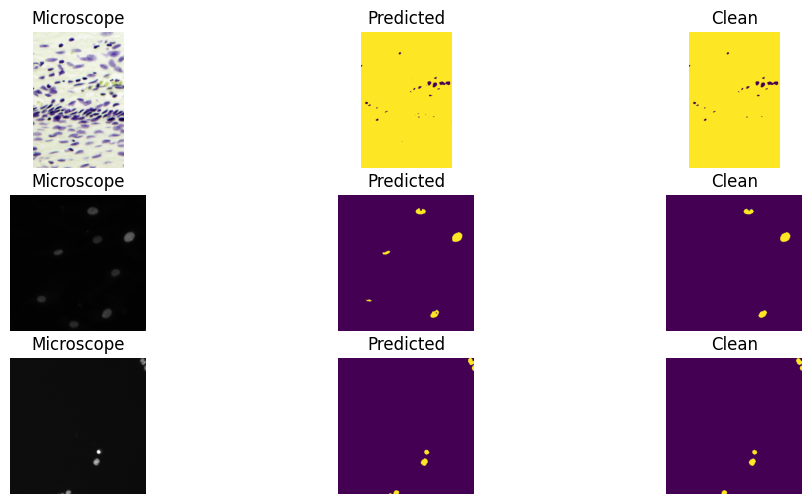

In [22]:
n_img = 3
from skimage.morphology import closing, opening, disk
def clean_img(x):
    return opening(closing(x, disk(1)), disk(3))
fig, m_axs = plt.subplots(3, n_img, figsize=(12, 6))
for (_, d_row), (c_im, c_lab, c_clean) in zip(test_img_df.sample(n_img).iterrows(), m_axs):
    c_im.imshow(d_row['images'])
    c_im.axis('off')
    c_im.set_title('Microscope')

    c_lab.imshow(d_row['masks'])
    c_lab.axis('off')
    c_lab.set_title('Predicted')

    c_clean.imshow(clean_img(d_row['masks']))
    c_clean.axis('off')
    c_clean.set_title('Clean')

## Check RLE

Check that our approach for RLE encoding (stolen from [here](https://www.kaggle.com/code/rakhlin/fast-run-length-encoding-python)) works

In [28]:
from skimage.morphology import label
def rle_encoding(x):
    '''
    x: numpy array of shape (height, width), 1 - mask, 0 - background
    Returns run length as list
    '''
    dots = np.where(x.T.flatten()==1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b>prev+1): run_lengths.extend((b+1, 0))
        run_lengths[-1] += 1
        prev = b
    return run_lengths

def prob_to_rles(x, cut_off = 0.5):
    lab_img = label(x > cut_off)
    if lab_img.max() < 1:
        lab_img[0, 0] = 1
    for i in range(1, lab_img.max() + 1):
        yield rle_encoding(lab_img==i)

## Calculate RLEs for a Train Image

In [29]:
_, train_rle_row = next(train_img_df.tail(5).iterrows())
train_row_rles = list(prob_to_rles(train_rle_row['masks']))

## Take the RLEs from the CSV

In [30]:
tl_rles = train_labels.query('ImageId=="{ImageId}"'.format(**train_rle_row))['EncodedPixels']

## Check

Since we made some simplifications, we don't expect everything to be perfect, but pretty close

In [31]:
match, mismatch = 0, 0
for img_rle, train_rle in zip(sorted(train_row_rles, key=lambda x: x[0]), sorted(tl_rles, key=lambda x: x[0])):
    for i_x, i_y in zip(img_rle, train_rle):
        if i_x == i_y:
            match += 1
        else:
            mismatch += 1
print('Matches: %d, Mismatches: %d, Accuracy: %2.1f%%' % (match, mismatch, 100.0*match/(match+mismatch)))

Matches: 360, Mismatches: 0, Accuracy: 100.0%


## Calculate RLE for all the masks

Here we generate the RLE for all the masks and output the results to a table. We use a few morphological operations to clean up the images before submission since they can be very messy (remove single pixels, connect nearby regions, etc)

In [32]:
test_img_df['rles'] = test_img_df['masks'].map(clean_img).map(lambda x: list(prob_to_rles(x)))

In [33]:
out_pred_list = []
for _, c_row in test_img_df.iterrows():
    for c_rle in c_row['rles']:
        out_pred_list += [dict(ImageId=c_row['ImageId'], EncodedPixels=' '.join(np.array(c_rle).astype(str)))]
out_pred_df = pd.DataFrame(out_pred_list)
print(out_pred_df.shape[0], 'regions found for', test_img_df.shape[0], 'images')
out_pred_df.sample(3)

1544 regions found for 65 images


,ImageId,EncodedPixels
396,43a71aeb641faa18742cb826772a8566c6c947d7050f9a...,39278 7 39536 13 39795 16 40055 18 40314 19 40...
322,432f367a4c5b5674de2e2977744d10289a064e5704b21a...,71496 3 72014 7 72532 12 73052 14 73571 16 740...
1231,d6eb7ce7723e2f6dc13b90b41a29ded27dbd815bad633f...,159255 1 159773 5 160293 5 160812 7 161332 8 1...


In [34]:
out_pred_df[['ImageId', 'EncodedPixels']].to_csv('predictions.csv', index=False)